In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

In [2]:
def black_scholes(S, K, T, r, sigma, option_type="Call"):

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == "Call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    else:
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    return price

print(black_scholes(S= 100, K= 100, T= 1, r = 0.05, sigma = 0.2, option_type="Call"))

10.450583572185565


In [3]:
def greeks(S, K, T, r, sigma):

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega = S * norm.pdf(d1) * np.sqrt(T)
    theta = (- (S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * norm.cdf(d2))

    return {'delta': delta, 'gamma': gamma, 'vega': vega, 'theta': theta}

print(greeks(S=100,K=100,T=1,r=0.05,sigma=0.2))

{'delta': np.float64(0.6368306511756191), 'gamma': np.float64(0.018762017345846895), 'vega': np.float64(37.52403469169379), 'theta': np.float64(-6.414027546438197)}


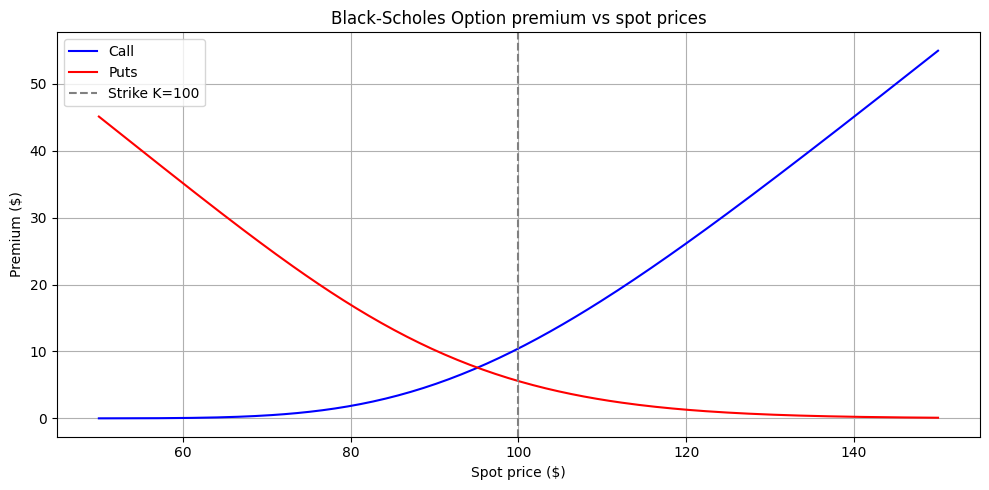

In [6]:
K, T, r, sigma = 100, 1, 0.05, 0.2
spots = np.linspace(50, 150, 200)

calls = [black_scholes(S, K, T, r, sigma, 'Call') for S in spots]
puts = [black_scholes(S, K, T, r, sigma, 'put') for S in spots]

plt.figure(figsize=(10,5))
plt.plot(spots, calls, label = 'Call', color = 'blue')
plt.plot(spots, puts, label = 'Puts', color = 'red')
plt.axvline(K, color = "gray", linestyle = '--', label = f'Strike K={K}')
plt.xlabel('Spot price ($)')
plt.ylabel('Premium ($)')
plt.title('Black-Scholes Option premium vs spot prices')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()